In [1]:
 # 1.Incarcarea setului de date

from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

In [5]:
 # 2.Afisarea primelor 5 randuri
import pandas as pd

df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [6]:
 # 3.Caracterisiticile

print("Caracteristicile disponibile sunt:", diabetes.feature_names)


Caracteristicile disponibile sunt: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [7]:
 # 4.Informatii statistice
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


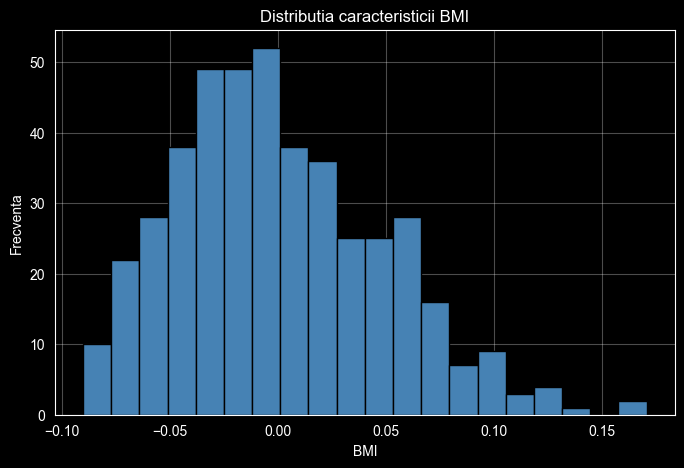

In [9]:
# 5. Histograma pentru caracteristica BMI

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['bmi'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distributia caracteristicii BMI')
plt.xlabel('BMI')
plt.ylabel('Frecventa')
plt.grid(True, alpha=0.3)
plt.show()

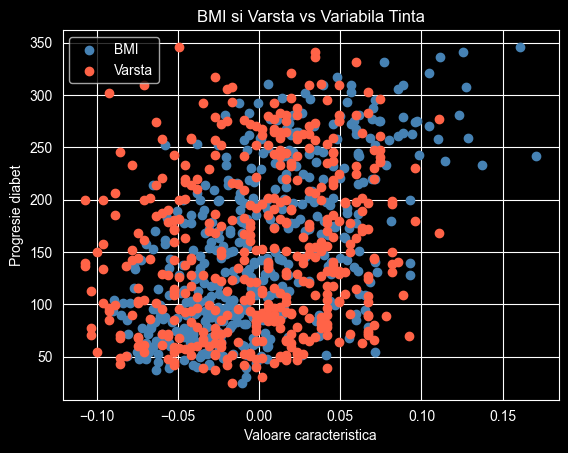

In [10]:
# 6. Grafic BMI si Varsta in functie de variabila tinta
import matplotlib.pyplot as plt

df['target'] = diabetes.target

plt.scatter(df['bmi'], df['target'], color='steelblue', label='BMI')
plt.scatter(df['age'], df['target'], color='tomato', label='Varsta')

plt.title('BMI si Varsta vs Variabila Tinta')
plt.xlabel('Valoare caracteristica')
plt.ylabel('Progresie diabet')
plt.legend()
plt.show()

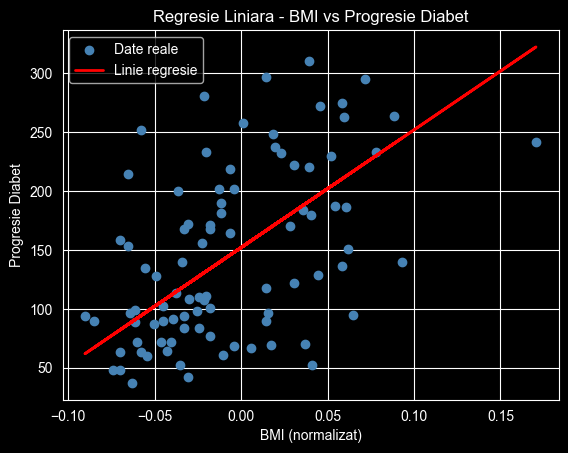

MSE: 4061.8259284949268


In [12]:
# 7. Regresie liniara simpla folosind BMI
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# a. Selectare BMI ca input si target
X = df[['bmi']]
y = df['target']

# b. Impartim datele
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# c. Antrenam modelul
model = LinearRegression()
model.fit(X_train, y_train)

# d. Grafic date de testare si linia de regresie
y_pred = model.predict(X_test)

plt.scatter(X_test, y_test, color='steelblue', label='Date reale')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Linie regresie')
plt.title('Regresie Liniara - BMI vs Progresie Diabet')
plt.xlabel('BMI (normalizat)')
plt.ylabel('Progresie Diabet')
plt.legend()
plt.show()

# e. Calculam MSE
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

In [14]:
# 8. Regresie liniara cu BMI si BP

# a. BMI si BP ca input
X2 = df[['bmi', 'bp']]
y = df['target']

# b. Antrenam noul model
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

# c. Afisam coeficientii
print("Coeficienti model:", model2.coef_)
print("Intercept:", model2.intercept_)

# d. Calculam scorul R^2
y2_pred = model2.predict(X2_test)
print("Scorul (R^2) este :", model2.score(X2_test, y2_test))

Coeficienti model: [839.51985334 393.45120312]
Intercept: 151.8153925749251
Scorul (R^2) este : 0.2939977566766083
